# Homework 2: Probability Models

BEE 4850/5850

**Name**: Luca Katzen

**ID**: 5360358

> **Due Date**
>
> Friday, 2/20/26, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice developing and
working with probability models for data.

-   Problem 1 asks you to fit some linear regressions to Chicago
    mortality data.
-   Problem 2 asks you to analyze the probability of Cayuga Lake
    freezing using a logistic regression model.
-   Problem 3 asks you to use Poisson regression to predict salamander
    counts based on environmental data.
-   Problem 4 asks you to look at the impact of the gender of hurricane
    names on deaths[1].

[1] Yes, seriously. Ish. Trust me, I know.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Documents/GitHub/hw02-LucaKatzen1-Spring26`
   Installed GR_jll ─────────────────── v0.73.22+0
   Installed Opus_jll ───────────────── v1.6.1+0
   Installed JpegTurbo_jll ──────────── v3.1.4+0
   Installed GR ─────────────────────── v0.73.22
   Installed PDMats ─────────────────── v0.11.37
   Installed Preferences ────────────── v1.5.1
   Installed Libmount_jll ───────────── v2.41.3+0
   Installed StaticArrays ───────────── v1.9.16
   Installed EnumX ──────────────────── v1.0.6
   Installed FiniteDiff ─────────────── v2.29.0
   Installed ADTypes ────────────────── v1.21.0
   Installed MuladdMacro ────────────── v0.2.4
   Installed JSON ───────────────────── v1.4.0
   Installed XZ_jll ─────────────────── v5.8.2+0
   Installed NLSolversBase ──────────── v8.0.0
   Installed StatsBase ──────────────── v0.34.10
   Installed NearestNeighbors ───────── v0.4.27
   Installed libpng_jll ─────────────── v1.6.54+0
   Installed PositiveFactorizations ─── v0.2.4
   Install

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [ ]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization tools
using LaTeXStrings # latex formatting for plot strings

## Problems

### Problem 1 (6 points)

Let’s revisit the `chicago` dataset from HW1 (found in
`data/chicago.csv`). We will look at the relationship of the potential
predictor variables `pm25median` (the median density of smaller
pollutant particles), `o3median` (the median concentration of O$_3$),
`so2median` (the median concentration of SO$_2$), and `tmpd` (mean daily
temperature) with the variable we would like to predict, `death` (the
number of non-accidental deaths on that day).

#### Problem 1.1

Plot each predictor variable against the response variable (make sure to
include labels and titles for each plot). Describe what you observe
about the bivariate relationships, if one exists (*e.g.* does it look
like they exist, are they linear, positive/negative, etc.) Does a linear
regression seem appropriate from any of these plots? Which predictor do
you think is most appropriate for a linear regression model and why?

#### Problem 1.2

You decide to focus on the relationship between `tmpd` and `death`. Your
classmate suggests that you use a Gaussian-error linear regression
model. Based on this suggestion, calculate the regression coefficients
and error variance. Explain the interpretation of the coefficients that
you obtain **in this specific problem context**.

#### Problem 1.3

Add your fitted regression line and a 90% prediction interval to your
scatterplot of `tmpd` and `death`. Using this and any other diagnostics,
do you agree with the Gaussian-error linear model assumption? Why or why
not?

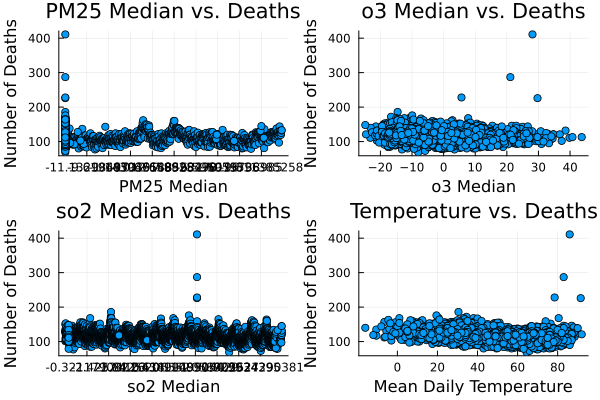

In [ ]:
#Problem 1.1
data = DataFrame(CSV.File("data/chicago.csv")) 

p1 = scatter(
    data.pm25median,
    data.death,
    xlabel = "PM25 Median",
    ylabel = "Number of Deaths",
    title = "PM25 Median vs. Deaths",
    legend = false
)

p2 = scatter(
    data.o3median,
    data.death,
    xlabel = "o3 Median",
    ylabel = "Number of Deaths",
    title = "o3 Median vs. Deaths",
    legend = false
)

p3 = scatter(
    data.so2median,
    data.death,
    xlabel = "so2 Median",
    ylabel = "Number of Deaths",
    title = "so2 Median vs. Deaths",
    legend = false
)

p4 = scatter(
    data.tmpd,
    data.death,
    xlabel = "Mean Daily Temperature",
    ylabel = "Number of Deaths",
    title = "Temperature vs. Deaths",
    legend = false
)

plot(p1, p2, p3, p4, layout = (2, 2))

##### Problem 1.1
None of the graphs appear to have strong or obvious bivariate correlations. While O3 displays some outliers at higher quantities, PM25, O3, and SO2 don't exhibit distinct linear patterns with deaths (the dots are dispersed without much visible direction). The most promising predictor is temperature, which exhibits a significant correlation with increases in mortality, particularly at the upper end of the temperature range. Temperature is the best candidate for a basic linear regression model since it exhibits a directional pattern that is worth modeling, even though there is still a lot of scatter. It also has the most pronounced linear trend of the four variables.

In [36]:
#Problem 1.2
X = hcat(ones(length(data.tmpd)), data.tmpd)
y = data.death

Beta = (X' * X) \ (X' * y)

yline = X * Beta
residuals = y - yline

n = length(y)
sigmasquared = sum(residuals.^2) / (n - 2)

println("Intercept: ", Beta[1])
println("Slope: ", Beta[2])
println("Error variance: ", sigmasquared)

Intercept: 129.95705121476817
Slope: -0.2896442961500982
Error variance: 202.31531425938184


##### Problem 1.2
The intercept (β₀) is the expected number of deaths on a day when the mean daily temperature is 0°F. The slope (β₁) is the expected change in the number of deaths for each 1°F increase in mean daily temperature. Because β₁ is negative, warmer days are not associated with more deaths. The error variance (σ²) represents how much the daily death counts vary around a linear trend, capturing variability due to other factors besides temperature. σ² is roughly 202 so predictions tend to be off by around 14 deaths.

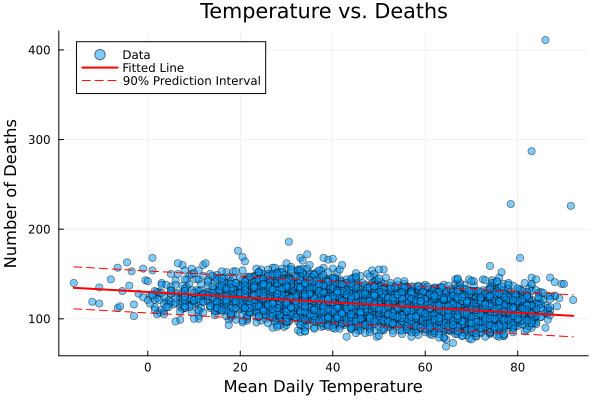

In [17]:
#Problem 1.3
X = hcat(ones(length(data.tmpd)), data.tmpd)
y = data.death
beta = (X' * X) \ (X' * y)
yline = X * beta
residuals = y - yline
n = length(y)
sigmasquared = sum(residuals.^2) / (n - 2)
sigma = sqrt(sigmasquared)

tmpdrange = range(minimum(data.tmpd), maximum(data.tmpd), length=100)
xpred = hcat(ones(length(tmpdrange)), tmpdrange)
ypred = xpred * beta

tval = quantile(TDist(n-2), 0.95)
sepred = sigma .* sqrt.(1 .+ sum((xpred * inv(X' * X)) .* xpred, dims=2))
predlower = ypred .- tval .* vec(sepred)
predupper = ypred .+ tval .* vec(sepred)

scatter(
    data.tmpd,
    data.death,
    xlabel = "Mean Daily Temperature",
    ylabel = "Number of Deaths",
    title = "Temperature vs. Deaths",
    label = "Data",
    alpha = 0.5
)
plot!(tmpdrange, ypred, 
    label = "Fitted Line", 
    color = :red, 
    linewidth = 2)
plot!(tmpdrange, predlower, 
    label = "90% Prediction Interval", 
    color = :red, 
    linestyle = :dash)
plot!(tmpdrange, predupper, 
    label = "", 
    color = :red, 
    linestyle = :dash)

##### Problem 1.3
I don't fully agree with the Gaussian-error linear model assumption. There are clear outliers with deaths exceeding 200-400 that fall well outside the 90% prediction interval, especially at higher temperatures on the scatter plot. The relationship also appears to have variability in deaths increases at higher temperatures. While overall there's a negative linear trend, the extreme outliers and non-constant variance suggest that the Gaussian assumption is not ideal. 

### Problem 2 (6 points)

This problem is adapted from Example 4.1 and 4.2 in Daniel Wilks’
*Statistical Methods in the Atmospheric Sciences*. Updating the table in
that book, Cayuga Lake has frozen in 1796, 1816, 1856, 1875, 1884, 1904,
1912, 1934, 1961, 1979, and 2015[1]. The probability of whether a severe
enough cold spell to freeze the lake occurs is related to changes in
global mean temperature. The file `data/HadCRUT5.1Analysis_gl.txt`
contains estimates of monthly global mean temperature anomalies (in
$^\circ$ C, relative to the 1961–1990 mean) as well as the annual global
temperature anomaly. You would like to build a model to predict the
probability that Cayuga Lake freezes based on the winter (DJF)
temperature anomaly.

#### Problem 2.1

Write down a logistic regression model for the probability that Cayuga
Lake freezes in a given winter. Encode the occurrence of freezing as a
1, and non-freezing as 0. Load the temperature data and fit this model.
The format of the data file is a little awkward, as the even rows are
the number of stations (which should be ignored) and have uneven number
of space delimiters. The first 13 columns are the year and the monthly
means; the final column is the annual average (which we don’t want to
use). Another complication is that the (even-numbered) station rows
don’t have an entry in the 14th column. In Julia, you can load the file
with

``` julia
temp_dat = CSV.read("data/HadCRUT5.1Analysis_gl.txt", delim=" ", 
    ignorerepeated=true, header=false, 
    silencewarnings=true, DataFrame) 
```

To simplify the analysis, since we don’t always know whether the lake
froze in the January starting a year or the December ending a year,
let’s assume that the years in which the lake froze correspond to the
winter starting the year (so the DJF mean corresponding to the freezing
in 1884 would include the December from 1883 and the January and
February from 1884). You will only be able to use freezing events
between 1851 and the present day due to the temperature data. Interpret
the coefficients from your model fit **in this specific problem
context**.

#### Problem 2.2

Plot the modeled probability of freezing as a function of the DFJ
temperature anomaly, and how this probability has changed over time.
Does this model seem reasonable? How might you determine this?

#### Problem 2.3

What winter temperature anomaly would be required for less than a 1%
probability of Cayuga Lake freezing?

In [35]:
data2 = CSV.read("data/HadCRUT5.1Analysis_gl.txt", delim=" ", 
    ignorerepeated=true, header=false, 
    silencewarnings=true, DataFrame)

oddrows = data2[1:2:end, :]
years = oddrows[2:end, 1]

djf = zeros(length(years))
for i in 1:length(years)
    dec_prev = oddrows[i, 13]
    jan_curr = oddrows[i+1, 2]
    feb_curr = oddrows[i+1, 3]
    djf[i] = (dec_prev + jan_curr + feb_curr) / 3
end

freezeyears = [1796, 1816, 1856, 1875, 1884, 1904, 1912, 1934, 1961, 1979, 2015]
freezeyears = freezeyears[freezeyears .>= 1851]

frozen = [year in freezeyears ? 1 : 0 for year in years]

logregdata = DataFrame(year = years, djf = djf, frozen = frozen)

println("DJF values when frozen: ", djf[frozen .== 1])

function logisticregression(X, y)
    function negloglikelihood(beta)
        eta = X * beta
        p = 1 ./ (1 .+ exp.(-eta))
        p = clamp.(p, 1e-10, 1 - 1e-10)
        return -sum(y .* log.(p) .+ (1 .- y) .* log.(1 .- p))
    end
    
    result = optimize(negloglikelihood, [0.0, -1.0], BFGS())
    return Optim.minimizer(result)
end

X = hcat(ones(length(logregdata.djf)), logregdata.djf)
y = logregdata.frozen

beta = logisticregression(X, y)

println("Intercept: ", beta[1])
println("Slope: ", beta[2])

DJF values when frozen: [-0.2793333333333333, -0.445, -0.37966666666666665, -0.7573333333333333, -0.3136666666666667, -0.331, 0.045000000000000005, -0.04066666666666666, 0.7276666666666668]
Intercept: -3.0163797707713482
Slope: -0.714206431276419


##### Problem 2.1
β₀ is the log-odds of Cayuga Lake freezing when the DJF temperature anomaly is 0°C (at the 1961-1990 baseline). β₁ is how the log-odds of freezing changes per 1°C increase in the DJF temperature anomaly. Since β₁ is negative, this means warmer winter temperatures decrease the probability that the lake will freeze. Because β₁ is roughly equal to -0.7, each 1°C increase in temperature anomaly reduces the log-odds of freezing by 0.7, or a moderate decrease in freezing probability.

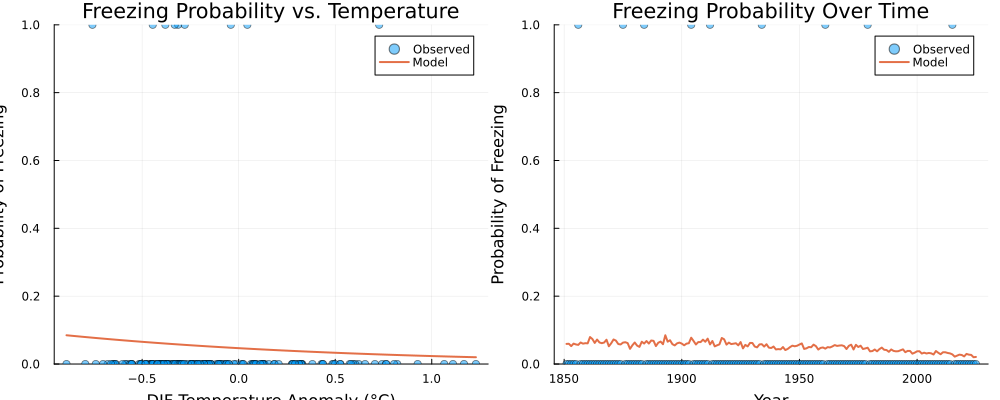

In [24]:
#Problem 2.2
djfrange = range(minimum(logregdata.djf), maximum(logregdata.djf), length=100)
xpred = hcat(ones(length(djfrange)), djfrange)
logodds = xpred * beta
probfreeze = 1 ./ (1 .+ exp.(-logodds))

p1 = scatter(logregdata.djf, logregdata.frozen,
    xlabel = "DJF Temperature Anomaly (°C)",
    ylabel = "Probability of Freezing",
    title = "Freezing Probability vs. Temperature",
    alpha = 0.5,
    label = "Observed")
plot!(djfrange, probfreeze,
    linewidth = 2,
    label = "Model",
    ylim = (0, 1))

xpredtime = hcat(ones(length(logregdata.djf)), logregdata.djf)
logoddstime = xpredtime * beta
probfreezetime = 1 ./ (1 .+ exp.(-logoddstime))

p2 = scatter(logregdata.year, logregdata.frozen,
    xlabel = "Year",
    ylabel = "Probability of Freezing",
    title = "Freezing Probability Over Time",
    alpha = 0.5,
    label = "Observed")
plot!(logregdata.year, probfreezetime,
    linewidth = 2,
    label = "Model",
    ylim = (0, 1))

plot(p1, p2, layout = (1, 2), size = (1000, 400))

##### Problem 2.2
The model seems reasonable overall. The probability of freezing decreases as temperature anomalies increase, which matches what you would expect logically. The probability of freezing over time shows a  decline, reflecting the understood impacts of global warming. However, the model might be oversimplified since it only uses one predictor and there are relatively few freezing events to train it on. To assess the model we could check how well it classifies historical freezing events, calculate metrics like accuracy, or use cross-validation to test its predictive performance.

In [25]:
function findtemperature(beta, targetprob)
    return (log(targetprob / (1 - targetprob)) - beta[1]) / beta[2]
end

temp1 = findtemperature(beta, 0.01)
println("DJF temperature anomaly for 1% freezing probability: ", temp1, "°C")

DJF temperature anomaly for 1% freezing probability: 2.2104814661802203°C


##### Problem 2.3
For less than a 1% probability of Cayuga Lake freezing, the DJF temperature anomaly would need to exceed approximately 2.2°C.

 ### Problem 3 (6 points) 
The file `data/salamanders.csv` contains counts of salamanders from 47, different plots of the same area in California, as well as the,percentage of ground cover and age of the forest in the plot. You would like to see if you can use these data to predict the salamander counts with a Poisson regression.
   
#### Problem 3.1
Write down and fit a Poisson regression model for salamander counts using the percentage of ground cover as a predictor. You may need to standardize the predictors as they are much larger than the counts, which you can do using the following function (or its equivalent):
[1] Many of these dates, particularly prior to the 20th century, are subject to some debate, and would be different depending on the data source. Nevertheless, let’s use this dataset.

#### Problem 3.2

Plot the expected counts and 90% prediction intervals from your model
(based on 1,000 simulations from the model) along with the data. How
well does the model predict the observed counts? In what ways does it do
a good or bad job?

#### Problem 3.3

Can you improve the model by including forest age as a predictor? How
did you determine whether this helps or does not help with prediction?

In [30]:
#Problem 3.1
data3 = DataFrame(CSV.File("data/salamanders.csv"))

function standardize(x)
    return (x .- mean(x)) ./ std(x)
end

data3.pct_cover_std = standardize(data3.PCTCOVER)

function poissonregression(X, y)
    function negloglikelihood(beta)
        lambda = exp.(X * beta)
        return -sum(y .* log.(lambda) .- lambda)
    end
    
    result = optimize(negloglikelihood, zeros(size(X, 2)), BFGS())
    return Optim.minimizer(result)
end

X = hcat(ones(nrow(data3)), data3.pct_cover_std)
y = data3.SALAMAN

beta = poissonregression(X, y)

println("Intercept (β₀): ", beta[1])
println("Slope (β₁): ", beta[2])

Intercept (β₀): 0.42951129115472364
Slope (β₁): 1.159506131879513


##### Problem 3.1
β₀ is the log expected salamander count when percent cover is at its mean value. β₁ is the change in log expected count for each one standard deviation increase in percent cover. Because β₁ is positive, more ground cover is associated with higher salamander counts. This makes sense because salamanders need moist habitat and more ground cover means more shade and moisture.

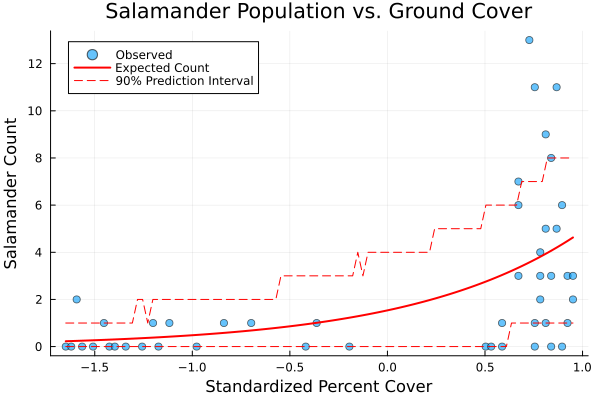

In [31]:
#Problem 3.2
coverrange = range(minimum(data3.pct_cover_std), maximum(data3.pct_cover_std), length=100)
xpred = hcat(ones(length(coverrange)), coverrange)
lambda = exp.(xpred * beta)

nsim = 1000
sims = zeros(length(coverrange), nsim)
for i in 1:length(coverrange)
    for j in 1:nsim
        sims[i, j] = rand(Poisson(lambda[i]))
    end
end

predlower = [quantile(sims[i, :], 0.05) for i in 1:length(coverrange)]
predupper = [quantile(sims[i, :], 0.95) for i in 1:length(coverrange)]

scatter(data3.pct_cover_std, data3.SALAMAN,
    xlabel = "Standardized Percent Cover",
    ylabel = "Salamander Count",
    title = "Salamander Population vs. Ground Cover",
    label = "Observed",
    alpha = 0.6)
plot!(coverrange, lambda,
    label = "Expected Count",
    linewidth = 2,
    color = :red)
plot!(coverrange, predlower,
    label = "90% Prediction Interval",
    color = :red,
    linestyle = :dash)
plot!(coverrange, predupper,
    label = "",
    color = :red,
    linestyle = :dash)

##### Problem 3.2
The model does an okay job at potraying the general trend of salamander counts with ground cover, but has some significant limitations. The most obvious issue is that many observed counts fall outside the 90% prediction intervals, especially at higher cover values. The biggest problem is overdispersion as the observed data is much more spread out than the Poisson model expects. Since Poisson assumes variance = mean, it underestimates the true variability in salamander counts. The wide scatter of points at a given cover level suggests other unmeasured factors are influencing counts, or that a different distribution would better model the variability in the data.


In [33]:
#Problem 3.3
data3.forest_age_std = standardize(data3.FORESTAGE)

X2 = hcat(ones(nrow(data3)), data3.pct_cover_std, data3.forest_age_std)
beta2 = poissonregression(X2, y)

println("Model with forest age:")
println("Intercept: ", beta2[1])
println("Slope for cover: ", beta2[2])
println("Slope for age: ", beta2[3])

lambda1 = exp.(X * beta)
lambda2 = exp.(X2 * beta2)

loglik1 = sum(y .* log.(lambda1) .- lambda1)
loglik2 = sum(y .* log.(lambda2) .- lambda2)

aic1 = -2 * loglik1 + 2 * length(beta)
aic2 = -2 * loglik2 + 2 * length(beta2)

println("\nModel 1 (cover only) AIC: ", aic1)
println("Model 2 (cover + age) AIC: ", aic2)
println("AIC improvement: ", aic1 - aic2)

Model with forest age:
Intercept: 0.4293187208268531
Slope for cover: 1.1624676135180043
Slope for age: -0.00408443026687972

Model 1 (cover only) AIC: -42.512375571960845
Model 2 (cover + age) AIC: -40.514172408183775
AIC improvement: -1.9982031637770703


##### Problem 3.3
I determined whether forest age can help to improve the model by comparing AIC values. Based on this, adding forest age does not appear to improve the model. The AIC actually increases slightly (gets worse) by about 2 when we add forest age as a predictor, suggesting the additional complexity isn't actually providing better fit. The slope for forest age is also very small (roughly -0.004), indicating that it has minimal effect on salamander counts. This suggests that once ground cover is accountted for, forest age doesn't provide additional useful information for predicting salamander counts, so the original model makes more sense.

### Problem 4 (7 points)

In 2014, [a paper was published in a prestigious
journal](https://www.pnas.org/doi/10.1073/pnas.1402786111) which claimed
that hurricanes with more feminine names are deadlier than hurricanes
with more masculine names because people take warnings about
female-named hurricanes less seriously[1]. The file
`data/Hurricanes.csv` contains the original data used in this analysis
(note that this dataset excludes Hurricanes Katrina and Audrey because
they were “outliers”). While we won’t replicate the specific analysis in
this paper, let’s use the data to look at this hypothesis.

#### Problem 4.1

One might interpret the hypothesis to claim that the impact of the name
is strengthened by the the more powerful. A measure of hurricane
strength is its minimum pressure (`min_pressure` in the dataset). Fit a
Poisson regression model that predicts deaths (`deaths`) using the
gender of the name (`female`) and minimum pressure (you may need to
standardize the pressure). We use `female` instead of the continuous
measure of the `femininity` of the name as this is highly subjective and
has some weird coding (such as “Sandy” being coded as one of the most
female names).

#### Problem 4.2

Interpret the results by generating 10,000 counterfactual simulations
for hurricanes with male and female names. Plot the expected values and
90% prediction intervals from these two sets of simulations and compare
with the observed storm deaths. Where does the model do well or not
well?

#### Problem 4.3

Does the gender effect size resulting from this model seem reasonable to
you? Draw on qualitative or quantitative assessments to justify your
assessment of reasonableness.

#### Problem 4.4

We can now stop taking this hypothesis seriously. To what extent do you
think the finding could be an artifact of the dataset (e.g. there is no
actual effect, but there are coincidental features of the data that
produce the result that female-named storms are more deadly than
male-named storms)? Justify this conclusion with specific reference to
an exploratory analysis of the data.

## References

[1] This paper has become a bit of a joke among statisticians, but let’s
take the hypothesis seriously for this problem’s sake.

In [34]:
#Problem 4.1
data4 = DataFrame(CSV.File("data/hurricanes.csv"))

data4.min_pressure_std = standardize(data4.min_pressure)

X = hcat(ones(nrow(data4)), data4.female, data4.min_pressure_std)
y = data4.deaths

beta = poissonregression(X, y)

println("Intercept: ", beta[1])
println("Slope for female: ", beta[2])
println("Slope for pressure: ", beta[3])

Intercept: 2.4146672367810664
Slope for female: 0.4721117391418284
Slope for pressure: -0.719532469950491


##### Problem 4.1
The intercept is the log expected deaths for a male-named hurricane at average minimum pressure. The slope coefficient for female is the change in log expected deaths when comparing female to male-named hurricanes, holding pressure constant. Because the intercept is positive, female-named hurricanes are related to a higher fatality rate. The coefficient for pressure shows how log expected deaths change with each standard deviation change in minimum pressure. This coefficient is negative because lower pressure means stronger storms and more deaths.

Male-named hurricanes:
Expected deaths: 14.6968
90% Prediction Interval: [3.0, 36.0]

Female-named hurricanes:
Expected deaths: 23.6239
90% Prediction Interval: [5.0, 56.0]


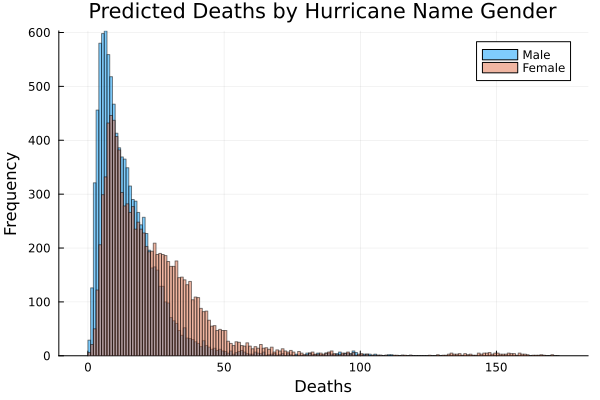

In [41]:
nsim = 10000

pressurevalues = rand(data4.min_pressure_std, nsim)

Xmale = hcat(ones(nsim), zeros(nsim), pressurevalues)
lambdamale = exp.(Xmale * beta)
simsmale = [rand(Poisson(lambdamale[i])) for i in 1:nsim]

Xfemale = hcat(ones(nsim), ones(nsim), pressurevalues)
lambdafemale = exp.(Xfemale * beta)
simsfemale = [rand(Poisson(lambdafemale[i])) for i in 1:nsim]

expectedmale = mean(simsmale)
expectedfemale = mean(simsfemale)
pimale = quantile(simsmale, [0.05, 0.95])
pifemale = quantile(simsfemale, [0.05, 0.95])

println("Male-named hurricanes:")
println("Expected deaths: ", expectedmale)
println("90% Prediction Interval: ", pimale)

println("\nFemale-named hurricanes:")
println("Expected deaths: ", expectedfemale)
println("90% Prediction Interval: ", pifemale)

histogram(simsmale, alpha=0.5, label="Male", bins=0:1:maximum([simsmale; simsfemale]))
histogram!(simsfemale, alpha=0.5, label="Female", bins=0:1:maximum([simsmale; simsfemale]))
xlabel!("Deaths")
ylabel!("Frequency")
title!("Predicted Deaths by Hurricane Name Gender")

##### Problem 4.2
This graph shows that female-named hurricanes tend to have higher expected deaths than male-named ones. However, the prediction intervals are very wide and have lots of overlap, indicating that this relationship is not likely causal. The model struggles with extreme right-skewness of the data as most hurricanes cause few deaths while a handful cause catastrophic casualties. The Poisson distribution doesn't adequately capture this overdispersion and the rare extreme events, but it does a good job at predicting the low-fatality storms.

##### Problem 4.3
The gender effect size is not reasonable. The model predicts female-named hurricanes cause about 60% more deaths on average (exp(0.47) equals roughly 1.6), but on the histogram, the distributions are highly overlapping with male-named storms only shifted slightly to the right. Both distributions are right-skewed, concentrated near 0-20 deaths with long tails extending to 150+ deaths. The proposed hypothesis that implicit bias against female names causes people to ignore warnings would need to be backed by other data/variables to prove its relationship with storm casualties. It's highly unlikely that name gender alone would cause such a substantial behavioral difference in people that they would override their self-preservation instincts during a dangerous hurricane.

Male-named storms:
Number: 30
Mean deaths: 14.233333333333333
Median deaths: 5.0
Max deaths: 84
Female-named storms:
Number: 62
Mean deaths: 23.758064516129032
Median deaths: 5.0
Max deaths: 256
Year distribution:
Male storms mean year: 1990.3333333333333
Female storms mean year: 1978.0967741935483


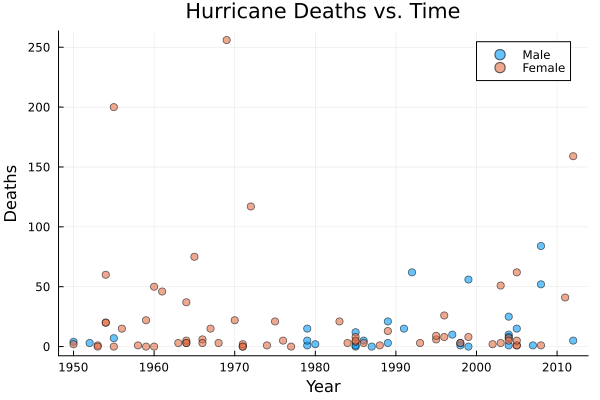

In [44]:
#Problem 4.4
println("Male-named storms:")
println("Number: ", sum(data4.female .== 0))
println("Mean deaths: ", mean(data4[data4.female .== 0, :deaths]))
println("Median deaths: ", median(data4[data4.female .== 0, :deaths]))
println("Max deaths: ", maximum(data4[data4.female .== 0, :deaths]))

println("Female-named storms:")
println("Number: ", sum(data4.female .== 1))
println("Mean deaths: ", mean(data4[data4.female .== 1, :deaths]))
println("Median deaths: ", median(data4[data4.female .== 1, :deaths]))
println("Max deaths: ", maximum(data4[data4.female .== 1, :deaths]))

println("Year distribution:")
println("Male storms mean year: ", mean(data4[data4.female .== 0, :year]))
println("Female storms mean year: ", mean(data4[data4.female .== 1, :year]))

scatter(data4.year, data4.deaths, 
    group=data4.female,
    xlabel="Year",
    ylabel="Deaths",
    title="Hurricane Deaths vs. Time",
    labels=["Male" "Female"],
    alpha=0.6)

##### Problem 4.4
The finding is likely an artifact of the dataset. The most obvious issue visible in this plot is that all hurricanes prior to 1979 had female names, and those early storms were clearly far deadlier. This makes sense logically and historically as before 1979, warning systems, forecasting technology, etc. were dramatically worse, meaning storms caused more deaths regardless of names. Once alternating male/female naming began in 1979, the death tolls for both genders look much more comparable and generally lower. So the idea that female names cause more deaths is really just that older storms were deadlier. The paper's failure to account for this historical change in predictive technology and hurricane infrasructure is its fundamental flaw.